Simulate the model by Euler-Maruyama with reset, taking $μ = θ = 1$ and $σ^2 = 0.25, 1, 4$. Histogram the subthreshold voltage and overlay $p(u)$ from part (a), and report the measured firing rate and the measured fraction of time below the reset against the predictions. Discard an initial transient before collecting statistics, and say why that matters here.

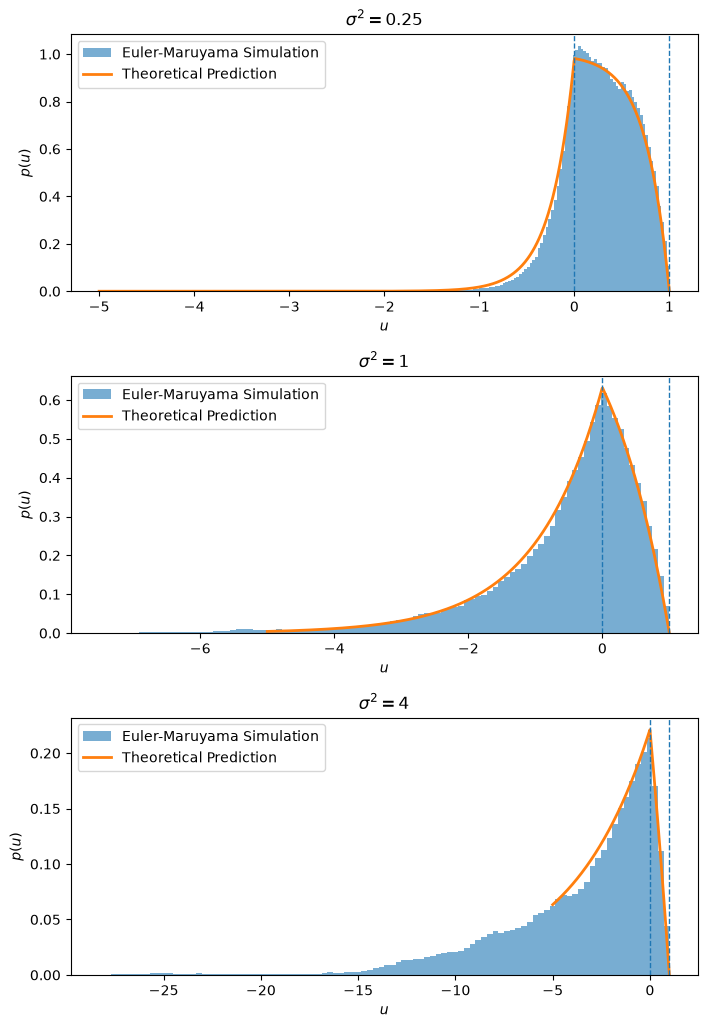

Comparison with theory
sigma^2 = 0.25 | firing rate: measured = 1.0133, predicted firing rate = 1.0000 | time below reset: measured = 0.2172, predicted time below reset = 0.2454
sigma^2 = 1.00 | firing rate: measured = 1.0156, predicted firing rate = 1.0000 | time below reset: measured = 0.6196, predicted time below reset = 0.6321
sigma^2 = 4.00 | firing rate: measured = 0.8789, predicted firing rate = 1.0000 | time below reset: measured = 0.8789, predicted time below reset = 0.8848


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Setup
mu = 1.0
theta = 1.0
sigma_sq_values = [0.25, 1, 4]
dt = 0.001
T = 1000
discard = 100

randnum = np.random.default_rng(0)

def Euler_Maruyama(mu, theta, sigma_sq, dt, T, discard):
    steps = int(T / dt)
    u = 0   # set u to zero for reset point
    u_histogram = []    # store data for histogram
    t_spike = []    # record time of spikes
    t = 0

    for i in range (steps):
        t += dt
        u += mu * dt + np.sqrt(2 * sigma_sq * dt) * randnum.standard_normal()   #Euler-Maruyama

        if u >= theta:  # record data when at threshold, reset to 0
            t_spike.append(t)
            u = 0.0

        if t >= discard:    # discarding the intiial transient
            u_histogram.append(u) 

    t_spike = np.array(t_spike)
    t_spike = t_spike[t_spike >= discard]   # only keep spike time data after discard period
    firing = len(t_spike) / (T - discard)   # measure firing rate taking into account discard removal
    below0 = np.mean(np.array(u_histogram) < 0)     # measure time below reset

    return np.array(u_histogram), t_spike, firing, below0

# run for sigma^2 = 0.25, 1, 4
results = {}

for sigma_sq in sigma_sq_values:
    u_histogram, t_spike, firing, below0 = Euler_Maruyama(mu, theta, sigma_sq, dt, T, discard)

    results[sigma_sq] = (u_histogram, firing, below0)

# build histogram
fig, axes = plt.subplots(3, 1, figsize = (7, 10))
plt.tight_layout(h_pad = 4)
u = np.linspace(-5, theta, 1000)

for axis, sigma_sq in zip(axes, sigma_sq_values):
    u_histogram, firing, below0 = results[sigma_sq]

    # Theoretical predictions
    pu_theory = np.where(
        u < 0,
        (1 - np.exp(-mu * theta / sigma_sq)) * np.exp(mu * u / sigma_sq), 
        1 - np.exp(mu * (u - theta) / sigma_sq)
    )

    axis.hist(
        u_histogram, 
        bins = 100, 
        density = True, 
        alpha = 0.6, 
        label = "Euler-Maruyama Simulation"
    )

    axis.plot(
        u,
        pu_theory,
        linewidth = 2, 
        label = "Theoretical Prediction"
    )

    axis.axvline(0, linestyle = "--", linewidth = 1)
    axis.axvline(theta, linestyle = "--", linewidth = 1)
    axis.set_title(rf"$\sigma^2 = {sigma_sq}$")
    axis.set_xlabel("$u$")
    axis.set_ylabel("$p(u)$")
    axis.legend()

plt.show()

# Compare experimental and theoretical
print("Comparison with theory")
for sigma_sq in sigma_sq_values:
        _, firing, below0 = results[sigma_sq]
        firing_theory = mu / theta
        below0_theory = sigma_sq / (mu * theta) * (1 - np.exp(-mu * theta / sigma_sq))

        print(
            f"sigma^2 = {sigma_sq:.2f} | "
            f"firing rate: measured = {firing:.4f}, "
            f"predicted firing rate = {firing_theory:.4f} | "
            f"time below reset: measured = {below0:.4f}, "
            f"predicted time below reset = {below0_theory:.4f}"
        )